In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder
# 원핫 인코더
from sklearn.preprocessing import OneHotEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import optuna
from optuna.samplers import TPESampler # 데이터를 랜덤샘플링하기 위함
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING) # 수치가 떨어지면 경고로그가 뜨는데 그거를 막아줌

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from catboost import CatBoostRegressor

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 연관규칙 학습
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth

# 파이프라인
from sklearn.pipeline import Pipeline

# KDE를 그리기 위한 통계값을 구할 수 있는 함수
from scipy.stats import gaussian_kde

# 피어슨 상관 계수 (연속형 수치형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pearsonr
# 카이제곱 검증 (범주형 데이터 vs 범주현 데이터, 순위 x)
from scipy.stats import chi2_contingency
# 스피어만 상관계수 (범주형 데이터 vs 범주형 데이터, 순위 O)
from scipy.stats import spearmanr
# 포인트 이분 상관계수 (범주형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pointbiserialr
# 독립 표본 T-검정 (독립관계를 같는 두 표본의 평균의 차이가 통계적으로 유의미한가)
from scipy.stats import ttest_ind

# 오버 샘플링
from imblearn.over_sampling import SMOTE

# 객체를 파일에 저장
import pickle

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 데이터 불러오기

In [2]:
df = pd.read_csv('data/Mall_Customers3.csv')
df

,Age,Income,Score,Is_Young,Spending_Ratio,Age_Income_Product,Gender_Numeric
0,19,15,39,1,2.600000,285,1
1,21,15,81,1,5.400000,315,1
2,20,16,6,1,0.375000,320,0
3,23,16,77,1,4.812500,368,0
4,31,17,40,1,2.352941,527,0
...,...,...,...,...,...,...,...
195,35,120,79,1,0.658333,4200,0
196,45,126,28,0,0.222222,5670,0
197,32,126,74,1,0.587302,4032,1
198,32,137,18,1,0.131387,4384,1


In [4]:
# 표준화
# 비지도학습이기 때문에 입력과 출력을 나누지 않고 데이터 전체로함
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled

array([[-1.42456879, -1.73899919, -0.43480148, ...,  1.57724431,
        -1.68953219,  1.12815215],
       [-1.28103541, -1.73899919,  1.19570407, ...,  4.46095966,
        -1.66496587,  1.12815215],
       [-1.3528021 , -1.70082976, -1.71591298, ..., -0.71427949,
        -1.66087149, -0.88640526],
       ...,
       [-0.49160182,  2.49780745,  0.92395314, ..., -0.49563044,
         1.37880101,  1.12815215],
       [-0.49160182,  2.91767117, -1.25005425, ..., -0.96517626,
         1.66704582,  1.12815215],
       [-0.6351352 ,  2.91767117,  1.27334719, ..., -0.47653836,
         1.44267344,  1.12815215]], shape=(200, 7))

### 군집 수행

In [6]:
# 모델 객체를 생성한다
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans

KMeans(n_clusters=5, random_state=42)

In [8]:
# 학습과 군집 할당
kmeans.fit(X_scaled)
# 군집을 생성한다.
clusters = kmeans.predict(X_scaled)
clusters

array([2, 2, 1, 2, 2, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 3, 0, 0, 1, 3, 0, 1, 0, 3, 1, 0, 0, 3, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 3, 1, 1, 0, 0, 0, 0, 3, 0, 0, 0, 1, 1, 0, 0, 4, 0, 4, 0,
       1, 1, 3, 1, 4, 3, 3, 1, 4, 3, 1, 1, 3, 3, 4, 1, 1, 3, 4, 0, 4, 0,
       4, 1, 4, 1, 3, 1, 4, 1, 3, 1, 4, 0, 4, 1, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 3, 4, 3, 4, 1, 4, 1, 4, 3, 4, 3, 4, 4, 4, 3, 3, 4, 4, 3, 4, 3,
       3, 3], dtype=int32)

In [9]:
# 각 군집별 중심점(Centroid)
centroid = kmeans.cluster_centers_
centroid

array([[ 0.92142611, -0.36128912, -0.19085519, -0.98019606, -0.20565895,
         0.21139184,  0.0392022 ],
       [-0.79739033, -0.02220465,  0.27917766,  1.02020406, -0.087888  ,
        -0.55261008, -0.66743163],
       [-0.97212662, -1.38385755,  1.02185099,  1.02020406,  2.36541584,
        -1.42140328, -0.01051073],
       [-0.77619387,  0.96708172,  0.22516505,  0.95122475, -0.40206855,
         0.10510798,  0.98921716],
       [ 0.47724849,  1.12643438, -1.02683028, -0.9087532 , -0.83867735,
         1.4079004 , -0.02302351]])

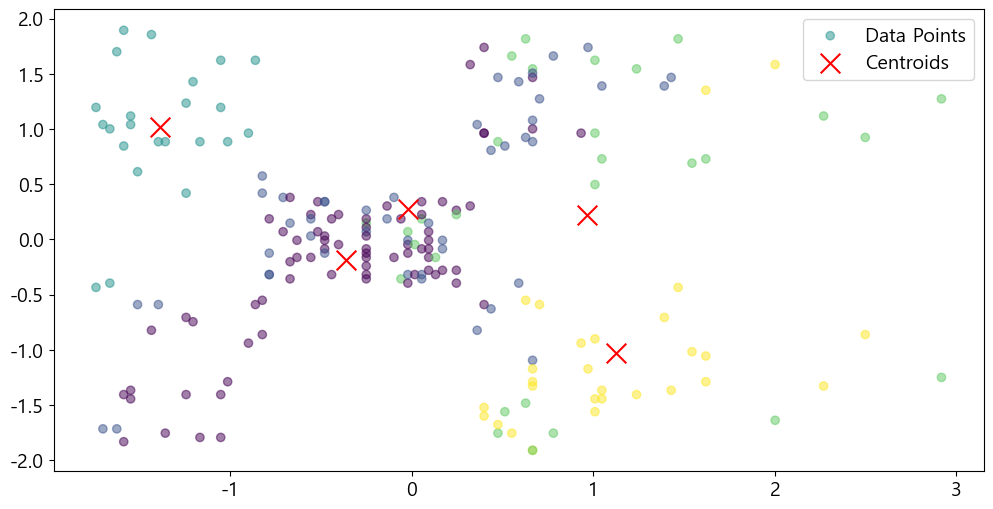

In [15]:
# 군집 결과 시각화
# EDA에서 Income과 Score에 따른 군집화 시각화
plt.scatter(X_scaled[:,1], X_scaled[:,2], c=clusters, cmap='viridis', 
            marker='o', alpha=0.5, label='Data Points')
# 중심점 표시
plt.scatter(centroid[:,1], centroid[:,2], c='red',marker='x', label='Centroids', s=200)
plt.legend()
plt.show()

In [16]:
# 결과를 가져온다.
labels = kmeans.predict(X_scaled)
labels

array([2, 2, 1, 2, 2, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 3, 0, 0, 1, 3, 0, 1, 0, 3, 1, 0, 0, 3, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 3, 1, 1, 0, 0, 0, 0, 3, 0, 0, 0, 1, 1, 0, 0, 4, 0, 4, 0,
       1, 1, 3, 1, 4, 3, 3, 1, 4, 3, 1, 1, 3, 3, 4, 1, 1, 3, 4, 0, 4, 0,
       4, 1, 4, 1, 3, 1, 4, 1, 3, 1, 4, 0, 4, 1, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 3, 4, 3, 4, 1, 4, 1, 4, 3, 4, 3, 4, 4, 4, 3, 3, 4, 4, 3, 4, 3,
       3, 3], dtype=int32)

In [17]:
df['Cluster'] = labels
df

,Age,Income,Score,Is_Young,Spending_Ratio,Age_Income_Product,Gender_Numeric,Cluster
0,19,15,39,1,2.600000,285,1,2
1,21,15,81,1,5.400000,315,1,2
2,20,16,6,1,0.375000,320,0,1
3,23,16,77,1,4.812500,368,0,2
4,31,17,40,1,2.352941,527,0,2
...,...,...,...,...,...,...,...,...
195,35,120,79,1,0.658333,4200,0,3
196,45,126,28,0,0.222222,5670,0,4
197,32,126,74,1,0.587302,4032,1,3
198,32,137,18,1,0.131387,4384,1,3


In [19]:
df['Cluster'].value_counts().sort_index()

Cluster
0    74
1    46
2    23
3    29
4    28
Name: count, dtype: int64

In [20]:
df.to_csv('data/Mall_CustomersResult.csv', index=False)